# Confidence-Based Classification with Reject Option

In this notebook, I implement a confidence-aware classification system using Logistic Regression.
Instead of always making a prediction, the model rejects predictions when confidence is low.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix


In [2]:
df = pd.read_csv('student-mat.csv', sep=';')
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [3]:
df['Result'] = (df['G3'] >= 10).astype(int)

features = ['studytime', 'failures', 'absences', 'G1', 'G2']

X = df[features]
y = df['Result']

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [5]:
baseline_preds = model.predict(X_test)
baseline_acc = accuracy_score(y_test, baseline_preds)

print('Baseline Accuracy (No Rejection):', round(baseline_acc, 4))

Baseline Accuracy (No Rejection): 0.8992


In [6]:
threshold = 0.7
probs = model.predict_proba(X_test)[:, 1]

preds = []
rejected = 0

for p in probs:
    if p >= threshold:
        preds.append(1)
    elif p <= 1 - threshold:
        preds.append(0)
    else:
        preds.append(None)
        rejected += 1

final_preds = []
final_true = []

for p, t in zip(preds, y_test):
    if p is not None:
        final_preds.append(p)
        final_true.append(t)

conf_acc = accuracy_score(final_true, final_preds)
rej_rate = rejected / len(y_test)

print('Accuracy (Confident Predictions):', round(conf_acc, 4))
print('Rejection Rate:', round(rej_rate, 4))

Accuracy (Confident Predictions): 0.9612
Rejection Rate: 0.1345


In [7]:
sample_students = X_test.iloc[:5]
sample_probs = model.predict_proba(sample_students)[:, 1]

for i, p in enumerate(sample_probs):
    print(f'Student {i+1} - Probability of Pass: {round(p,4)}')
    
    if p >= threshold:
        print('Decision: PASS')
    elif p <= 1 - threshold:
        print('Decision: FAIL')
    else:
        print('Decision: REJECTED')
    
    print()

Student 1 - Probability of Pass: 0.1645
Decision: FAIL

Student 2 - Probability of Pass: 0.9988
Decision: PASS

Student 3 - Probability of Pass: 0.0002
Decision: FAIL

Student 4 - Probability of Pass: 0.3917
Decision: REJECTED

Student 5 - Probability of Pass: 0.3904
Decision: REJECTED



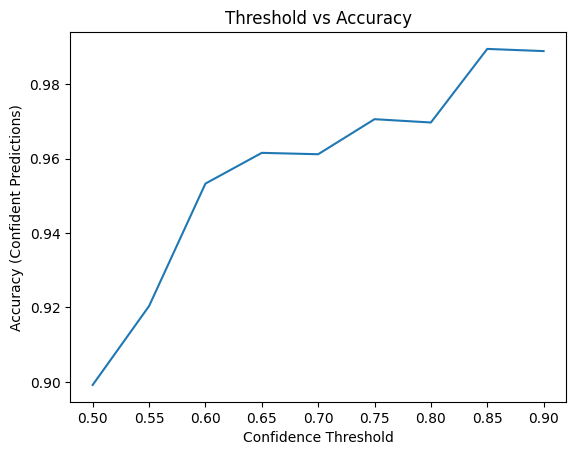

In [8]:
thresholds = np.arange(0.5, 0.95, 0.05)
accuracies = []

for t in thresholds:
    temp_preds = []
    temp_true = []
    
    for p, true in zip(probs, y_test):
        if p >= t:
            temp_preds.append(1)
            temp_true.append(true)
        elif p <= 1 - t:
            temp_preds.append(0)
            temp_true.append(true)
    
    if temp_preds:
        accuracies.append(accuracy_score(temp_true, temp_preds))
    else:
        accuracies.append(0)

plt.figure()
plt.plot(thresholds, accuracies)
plt.xlabel('Confidence Threshold')
plt.ylabel('Accuracy (Confident Predictions)')
plt.title('Threshold vs Accuracy')
plt.show()

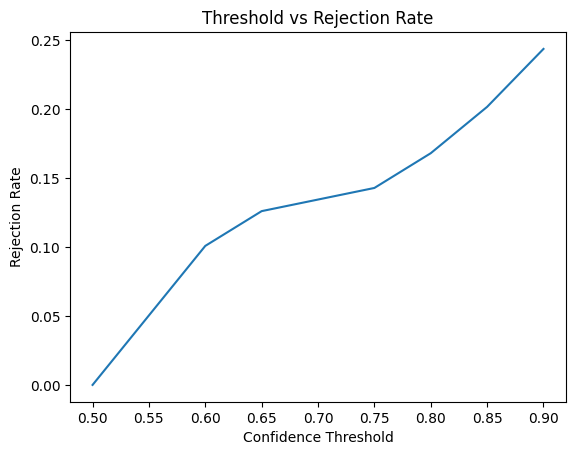

In [9]:
rejections = []

for t in thresholds:
    count = 0
    for p in probs:
        if not (p >= t or p <= 1 - t):
            count += 1
    
    rejections.append(count / len(y_test))

plt.figure()
plt.plot(thresholds, rejections)
plt.xlabel('Confidence Threshold')
plt.ylabel('Rejection Rate')
plt.title('Threshold vs Rejection Rate')
plt.show()

## Conclusion

Increasing the confidence threshold improves the accuracy of accepted predictions but increases rejection rate.
This shows the trade-off between prediction coverage and reliability in confidence-based classification.
